# Capstone EDA — Customer Lifetime Value

**Dataset** `data/synthetic_data_126.csv` — 1,000 customers × 7 columns
**Task** regression: predict `estimated_lifetime_value` from RFM-style customer features
**Companion** `readme.md` — the literature review this notebook puts into practice

| § | Section |
|---|---------|
| 1 | Setup & load |
| 2 | Data overview & quality checks |
| 3 | The target: heavy tail and value concentration |
| 4 | Features and their relation to value |
| 5 | The loyalty paradox — why a marginal correlation misleads |
| 6 | Can this data support a BTYD model? |
| 7 | The structure of the target — a power law |
| 8 | Modelling set-up: split, metrics, protocol |
| 9 | Model selection — 7 candidates, cross-validated |
| 10 | Hyperparameter tuning of the finalists |
| 11 | Final model — held-out test evaluation |
| 12 | What drives value, and what the model recovered |
| 13 | Turning predictions into customer tiers |
| 14 | Conclusions & limitations |

> **Read §14 before quoting any number above it.** The target in this file is an *already
> estimated* lifetime value, not observed spend over a future window, and §7 shows it is
> a near-deterministic function of the features. The high scores below measure how well a
> model **recovers a generating formula**, not how well it forecasts customer behaviour.
> `readme.md` §9 sets out what would be needed for the latter.

## 1. Setup & load

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import loguniform, randint, uniform
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (KFold, RandomizedSearchCV, cross_val_predict,
                                     cross_validate, train_test_split)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
# The mean baseline predicts a constant, so its rank correlation is undefined by design.
warnings.filterwarnings("ignore", category=stats.ConstantInputWarning)
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42
DATA_PATH = "data/synthetic_data_126.csv"
TARGET = "estimated_lifetime_value"

# Chart colours: one accent, one contrast, recessive everything else.
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#8a8984"
sns.set_theme(style="white", rc={
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK, "ytick.color": INK, "axes.titleweight": "bold",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "figure.dpi": 110,
})

raw = pd.read_csv(DATA_PATH)
raw.head()

,total_purchase_count,average_order_value,days_since_first_purchase,days_since_last_purchase,product_category_diversity,loyalty_program_membership,estimated_lifetime_value
0,12.440,40.71,309.32,52.28,0.0317,Not Enrolled,415.06
1,43.160,155.18,810.47,82.61,0.4750,Not Enrolled,1790.00
2,0.699,58.41,298.51,203.12,0.1210,Enrolled,186.94
3,9.750,44.82,220.62,37.30,0.2160,Not Enrolled,475.64
4,5.550,48.76,198.76,45.66,0.0633,Enrolled,485.83


## 2. Data overview & quality checks

In [2]:
print("shape:", raw.shape)
pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_missing": raw.isna().sum(),
    "n_unique": raw.nunique(),
    "min": raw.min(numeric_only=True),
    "median": raw.median(numeric_only=True),
    "max": raw.max(numeric_only=True),
})

shape: (1000, 7)


,dtype,n_missing,n_unique,min,median,max
average_order_value,float64,0,966,17.87000,73.070,848.170
days_since_first_purchase,float64,0,991,7.54000,305.275,1494.160
days_since_last_purchase,float64,0,967,1.62000,78.715,450.040
estimated_lifetime_value,float64,0,997,58.64000,536.355,16797.340
loyalty_program_membership,str,0,2,NaN,NaN,NaN
product_category_diversity,float64,0,548,0.00522,0.259,0.783
total_purchase_count,float64,0,830,0.03050,5.010,844.220


In [3]:
checks = {
    "rows": len(raw),
    "duplicate rows": int(raw.duplicated().sum()),
    "missing cells": int(raw.isna().sum().sum()),
    "zero-value customers": int((raw[TARGET] == 0).sum()),
    "non-positive target": int((raw[TARGET] <= 0).sum()),
    "non-integer purchase counts": int((raw["total_purchase_count"] % 1 != 0).sum()),
    "last purchase before first": int((raw["days_since_last_purchase"]
                                      > raw["days_since_first_purchase"]).sum()),
    "purchase count < 1": int((raw["total_purchase_count"] < 1).sum()),
}
pd.Series(checks).to_frame("value")

,value
rows,1000
duplicate rows,0
missing cells,0
zero-value customers,0
non-positive target,0
non-integer purchase counts,988
last purchase before first,52
purchase count < 1,143


**Three findings that shape everything downstream.**

1. **No zero-value customers** (minimum 58.64). The zero-inflation machinery that dominates the
   CLV literature — two-stage hurdle models, the ZILN loss (`readme.md` §5.1) — solves a problem
   this dataset does not have. Worth saying out loud, because it is the first thing a reviewer looks for.
2. **`total_purchase_count` is non-integer on almost every row** (988 of 1,000 — e.g. 12.44
   purchases), and **143 customers have fewer than one purchase** (as low as 0.03) while still
   having an order value and a lifetime value. Real purchase counts are integers and a customer
   cannot buy a third of a time. This is the clearest sign that the file is generated rather than observed.
3. **52 customers have a last purchase *before* their first purchase.** Under the standard RFM
   mapping this implies a negative recency, which is impossible (§6).

None of these are errors to "fix" — they are evidence about what the file *is*. They are carried
forward as constraints on what may be claimed from it (§6, §14), not silently repaired.

## 3. The target: heavy tail and value concentration

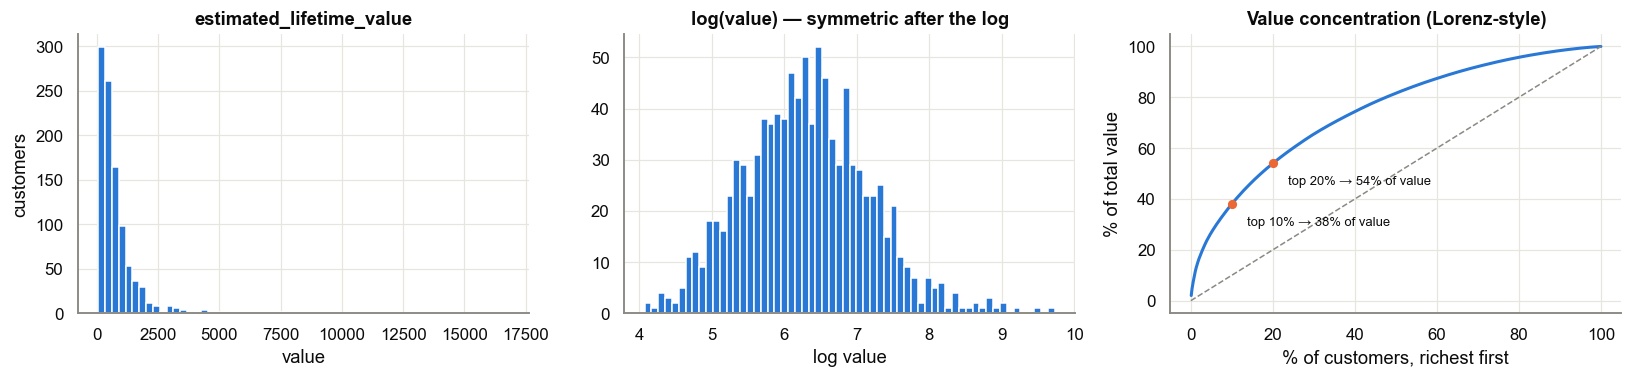

mean                   827.74
median                 536.36
std                   1133.26
skew                     6.40
excess kurtosis         62.83
max / median            31.32
skew of log(value)       0.31


In [4]:
y_all = raw[TARGET]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].hist(y_all, bins=60, color=BLUE)
axes[0].set(title="estimated_lifetime_value", xlabel="value", ylabel="customers")
axes[1].hist(np.log(y_all), bins=60, color=BLUE)
axes[1].set(title="log(value) — symmetric after the log", xlabel="log value")

share = np.sort(y_all)[::-1].cumsum() / y_all.sum()
pct = np.arange(1, len(y_all) + 1) / len(y_all)
axes[2].plot(pct * 100, share * 100, color=BLUE, lw=2)
axes[2].plot([0, 100], [0, 100], color=MUTED, ls="--", lw=1)
for q in (0.1, 0.2):
    axes[2].annotate(f"top {q:.0%} → {share[int(q * len(y_all)) - 1]:.0%} of value",
                     (q * 100, share[int(q * len(y_all)) - 1] * 100),
                     xytext=(10, -14), textcoords="offset points", fontsize=8.5, color=INK)
    axes[2].scatter([q * 100], [share[int(q * len(y_all)) - 1] * 100], color=ORANGE, zorder=3, s=25)
axes[2].set(title="Value concentration (Lorenz-style)", xlabel="% of customers, richest first",
            ylabel="% of total value")
plt.tight_layout(); plt.show()

print(pd.Series({
    "mean": y_all.mean(), "median": y_all.median(), "std": y_all.std(),
    "skew": y_all.skew(), "excess kurtosis": y_all.kurtosis(),
    "max / median": y_all.max() / y_all.median(),
    "skew of log(value)": np.log(y_all).skew(),
}).round(2).to_string())

The target is strongly right-skewed (skew 6.4, max 31× the median) and **the top 10% of customers
hold 38% of total value**. Two consequences, both standard in this literature (`readme.md` §2):

* **Model `log(value)`, not `value`.** The log is near-symmetric, so squared-error loss stops being
  dominated by a handful of high-value customers. Predictions are transformed back for reporting (§8).
* **Rank metrics matter more than error metrics.** Marketing budget is allocated by *ordering*
  customers, so Spearman correlation and the normalized Gini coefficient are the headline
  measures, with decile calibration beside them.

## 4. Features and their relation to value

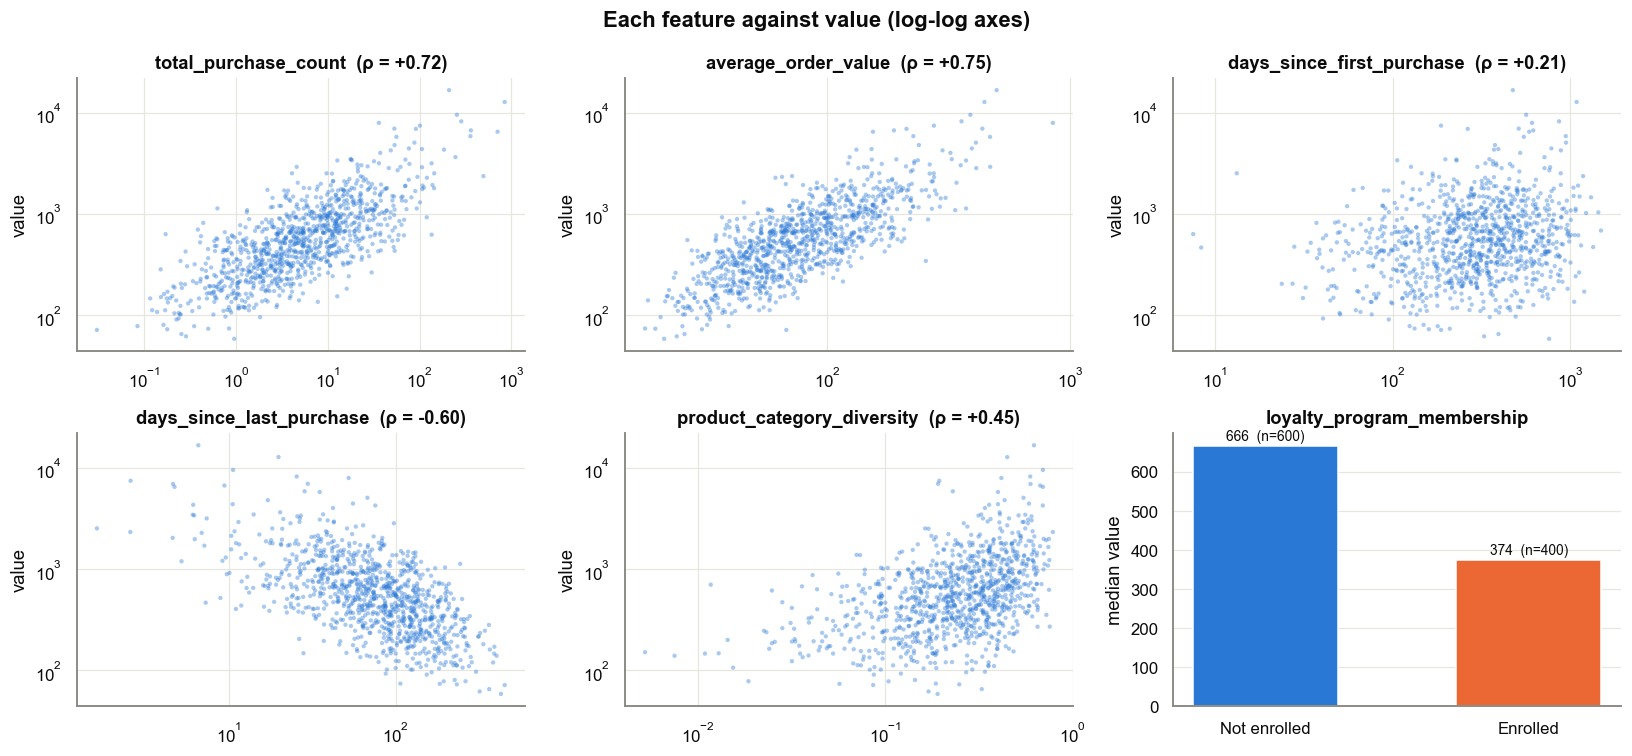

In [5]:
df = raw.copy()
df["loyalty"] = (df["loyalty_program_membership"] == "Enrolled").astype(int)
NUMERIC = ["total_purchase_count", "average_order_value", "days_since_first_purchase",
           "days_since_last_purchase", "product_category_diversity"]
FEATURES = NUMERIC + ["loyalty"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), NUMERIC):
    ax.scatter(df[col], df[TARGET], s=8, alpha=0.4, color=BLUE, edgecolors="none")
    rho = stats.spearmanr(df[col], df[TARGET])[0]
    ax.set(title=f"{col}  (ρ = {rho:+.2f})", xlabel="", ylabel="value",
           xscale="log", yscale="log")
g = df.groupby("loyalty")[TARGET]
axes.ravel()[5].bar(["Not enrolled", "Enrolled"], g.median(), color=[BLUE, ORANGE], width=0.55)
for i, (m, n) in enumerate(zip(g.median(), g.size())):
    axes.ravel()[5].text(i, m + 15, f"{m:,.0f}  (n={n})", ha="center", fontsize=9)
axes.ravel()[5].set(title="loyalty_program_membership", ylabel="median value")
axes.ravel()[5].grid(axis="x", visible=False)
fig.suptitle("Each feature against value (log-log axes)", fontweight="bold")
plt.tight_layout(); plt.show()

In [6]:
rows = []
for col in FEATURES:
    rows.append({
        "feature": col,
        "spearman_vs_value": stats.spearmanr(df[col], df[TARGET])[0],
        "pearson_log_log": (np.corrcoef(np.log(df[col]), np.log(df[TARGET]))[0, 1]
                            if col in NUMERIC else np.nan),
    })
assoc = pd.DataFrame(rows).set_index("feature").round(3)
assoc.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1)

,spearman_vs_value,pearson_log_log
feature,,
total_purchase_count,0.722000,0.741000
average_order_value,0.751000,0.773000
days_since_first_purchase,0.213000,0.219000
days_since_last_purchase,-0.598000,-0.616000
product_category_diversity,0.455000,0.449000
loyalty,-0.344000,nan


On log-log axes the relationships are close to **straight lines**, which is the visual signature of a
multiplicative (power-law) relationship — pursued in §7.

`average_order_value` (ρ = +0.75) and `total_purchase_count` (ρ = +0.72) lead, and
`days_since_last_purchase` is strongly negative (ρ = −0.60): recency matters, exactly as the RFM
tradition predicts. `days_since_first_purchase` (tenure) is weak, and **`loyalty` looks negative**
(ρ = −0.34), which is the opposite of what a loyalty programme should do. That is worth a section
of its own.

## 5. The loyalty paradox — why a marginal correlation misleads

In [7]:
print("median feature values by loyalty status")
print(df.groupby("loyalty")[NUMERIC + [TARGET]].median().round(2).to_string())
print("\ncorrelation between loyalty and each feature:")
for col in NUMERIC:
    print(f"  {col:28s} ρ = {stats.spearmanr(df['loyalty'], df[col])[0]:+.3f}")

median feature values by loyalty status
         total_purchase_count  average_order_value  days_since_first_purchase  days_since_last_purchase  product_category_diversity  estimated_lifetime_value
loyalty                                                                                                                                                      
0                        8.96                86.07                     334.86                     66.09                        0.31                    665.82
1                        2.25                60.67                     270.03                    104.63                        0.19                    373.84

correlation between loyalty and each feature:
  total_purchase_count         ρ = -0.446
  average_order_value          ρ = -0.254
  days_since_first_purchase    ρ = -0.155
  days_since_last_purchase     ρ = +0.275
  product_category_diversity   ρ = -0.304


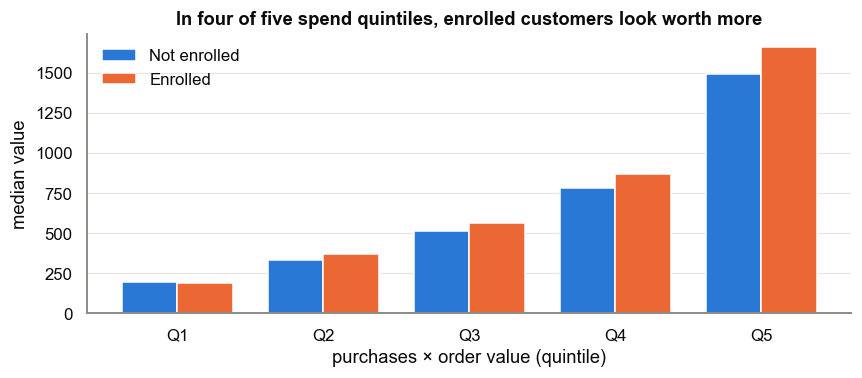

,Not enrolled,Enrolled,uplift
driver_bucket,,,
Q1,195,192,-1.3%
Q2,335,370,+10.2%
Q3,515,563,+9.4%
Q4,784,868,+10.7%
Q5,"1,494","1,661",+11.1%


In [8]:
# Compare like with like: bucket customers by spend level, then look at loyalty inside each bucket.
df["value_driver"] = df["total_purchase_count"] * df["average_order_value"]
df["driver_bucket"] = pd.qcut(df["value_driver"], 5, labels=[f"Q{i}" for i in range(1, 6)])
pivot = df.pivot_table(index="driver_bucket", columns="loyalty", values=TARGET,
                       aggfunc="median", observed=True)
pivot.columns = ["Not enrolled", "Enrolled"]

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(pivot))
ax.bar(x - 0.19, pivot["Not enrolled"], width=0.38, color=BLUE, label="Not enrolled")
ax.bar(x + 0.19, pivot["Enrolled"], width=0.38, color=ORANGE, label="Enrolled")
ax.set(xticks=x, xticklabels=pivot.index, xlabel="purchases × order value (quintile)",
       ylabel="median value", title="In four of five spend quintiles, enrolled customers look worth more")
ax.legend(frameon=False); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
(pivot.assign(uplift=lambda t: t["Enrolled"] / t["Not enrolled"] - 1)
      .style.format({"Not enrolled": "{:,.0f}", "Enrolled": "{:,.0f}", "uplift": "{:+.1%}"}))

**A textbook Simpson's paradox — at first.** Loyalty-programme members look *less* valuable overall
(ρ = −0.34) only because they are concentrated among low-frequency, low-spend customers: their
median purchase count is 2.25 against 8.96 for non-members. Compare customers at a similar spend
level and the sign flips: enrolled customers look *more* valuable in most quintiles.

But "control for spend level" is itself a modelling choice, and the answer turns out to depend on
how well the rest of the model is specified. §7 settles it properly.

### How much of that flip survives a better-specified model?

In [9]:
# Fit value from the numeric features ONLY (out-of-fold), then ask whether loyalty
# explains anything left over. If enrolment has an effect, members' residuals sit above zero.
from sklearn.model_selection import cross_val_predict as _cvp

log_numeric = np.log(df[NUMERIC])
log_numeric.columns = [f"log_{c}" for c in NUMERIC]
y_log_all = np.log(df[TARGET])
_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

specs = {}
for label, model in {
    "degree-1 (log-log linear)": LinearRegression(),
    "degree-3 (log-log polynomial)": Pipeline([
        ("poly", PolynomialFeatures(3, include_bias=False)),
        ("scale", StandardScaler()), ("ridge", Ridge(alpha=0.01))]),
}.items():
    residual = y_log_all - _cvp(model, log_numeric, y_log_all, cv=_cv)
    gap = residual[df["loyalty"] == 1].mean() - residual[df["loyalty"] == 0].mean()
    t_stat, p_value = stats.ttest_ind(residual[df["loyalty"] == 1],
                                      residual[df["loyalty"] == 0], equal_var=False)
    specs[label] = {"implied effect of enrolment": f"{100 * (np.exp(gap) - 1):+.2f}%",
                    "t": round(float(t_stat), 2), "p-value": round(float(p_value), 3)}

pd.DataFrame({
    "marginal (raw correlation)": {"implied effect of enrolment":
                                   f"ρ = {stats.spearmanr(df['loyalty'], df[TARGET])[0]:+.2f}",
                                   "t": np.nan, "p-value": np.nan},
    **specs,
}).T

,implied effect of enrolment,t,p-value
marginal (raw correlation),ρ = -0.34,NaN,NaN
degree-1 (log-log linear),+15.72%,20.81,0.0
degree-3 (log-log polynomial),+0.12%,1.48,0.14


**Three specifications, three different answers:**

| Specification | Apparent effect of enrolment |
|---|---|
| Raw correlation | **negative** (ρ = −0.34) |
| Degree-1 log-log model | **about +16%**, apparently decisive |
| Degree-3 log-log model (the one that actually fits, §7) | **+0.1%, p ≈ 0.14 — nothing** |

The middle row is the trap. Controlling for the other features *partially* — with a model whose
functional form is wrong — manufactures a large, confident-looking loyalty effect out of
mis-specification. Once the numeric features are given a form that genuinely fits the data, the
residual gap vanishes: **enrolment carries no independent information about value in this dataset.**

The lesson is stronger than the usual "correlation is not causation": **an effect estimated from a
mis-specified model is not an effect either**, and its sign and size can be pure artefact. Anyone
reporting the +16% would have had a plausible regression table to back it up.

## 6. Can this data support a BTYD model?

`readme.md` §3 makes the case for BG/NBD + Gamma-Gamma as the domain-standard reference model,
and Fader, Hardie & Lee's result that RFM is a *sufficient statistic* for future value is what
makes a summary file like this one usable at all. So: can it be fitted here?

In [10]:
btyd = pd.DataFrame({
    "frequency": df["total_purchase_count"] - 1,                 # repeat purchases
    "T": df["days_since_first_purchase"],                        # customer age
    "recency": df["days_since_first_purchase"] - df["days_since_last_purchase"],
    "monetary_value": df["average_order_value"],
})
issues = {
    "non-integer frequency": int((btyd["frequency"] % 1 != 0).sum()),
    "negative frequency": int((btyd["frequency"] < 0).sum()),
    "negative recency (last purchase before first)": int((btyd["recency"] < 0).sum()),
    "recency > T": int((btyd["recency"] > btyd["T"]).sum()),
}
print(pd.Series(issues).to_frame("rows failing").to_string())
btyd.describe().T.round(2)

                                               rows failing
non-integer frequency                                   988
negative frequency                                      143
negative recency (last purchase before first)            52
recency > T                                               0


,count,mean,std,min,25%,50%,75%,max
frequency,1000.0,14.97,47.69,-0.97,0.88,4.01,12.50,843.22
T,1000.0,364.10,251.46,7.54,176.79,305.27,494.98,1494.16
recency,1000.0,268.99,230.86,-262.41,93.54,215.16,383.57,1292.95
monetary_value,1000.0,94.22,70.60,17.87,49.44,73.07,115.94,848.17


**Verdict: not credibly.** BG/NBD needs integer repeat-purchase counts and a recency that lies
between 0 and the customer's age T. Here 988 of 1,000 frequencies are non-integer, 52 recencies are
negative, and — decisively — **the file has no transaction timestamps and no future window**, so
there is nothing for a BTYD model to forecast *into*.

Fitting one would require rounding counts and dropping or clipping the impossible rows, and the
output would describe the rounding as much as the customers. It is left out, and `readme.md` §9
records what data would be needed to do it properly.

This section is a negative result, and negative results belong in an EDA: the reason a standard
method was **not** used is as informative as the method that was.

## 7. The structure of the target — a power law

The log-log scatter plots in §4 suggest a multiplicative form. If

$$\text{value} = e^{\beta_0}\cdot x_1^{\beta_1}\cdot x_2^{\beta_2}\cdots e^{\beta_k \cdot \text{loyalty}}\cdot \varepsilon$$

then taking logs makes it a *linear* model in the logged features. Testing this is the single most
informative thing that can be done with this dataset.

In [11]:
log_features = np.log(df[NUMERIC])
log_features.columns = [f"log_{c}" for c in NUMERIC]
X_log = log_features.assign(loyalty=df["loyalty"])
y_log = np.log(df[TARGET])

ols = LinearRegression().fit(X_log, y_log)
resid = y_log - ols.predict(X_log)
coefs = (pd.Series(ols.coef_, index=X_log.columns)
         .to_frame("coefficient")
         .assign(interpretation=lambda t: [
             f"+1% in feature → {c:+.2f}% in value" if not n.startswith("loyalty")
             else f"enrolment → {100 * (np.exp(c) - 1):+.1f}% in value"
             for n, c in zip(t.index, t["coefficient"])]))
print(f"in-sample R² on log(value): {ols.score(X_log, y_log):.4f}")
print(f"intercept: {ols.intercept_:.3f}   residual std (log): {resid.std():.4f}")
coefs.round(3)

in-sample R² on log(value): 0.9872
intercept: 3.446   residual std (log): 0.0979


,coefficient,interpretation
log_total_purchase_count,0.293,+1% in feature → +0.29% in value
log_average_order_value,0.863,+1% in feature → +0.86% in value
log_days_since_first_purchase,-0.015,+1% in feature → -0.02% in value
log_days_since_last_purchase,-0.321,+1% in feature → -0.32% in value
log_product_category_diversity,-0.005,+1% in feature → -0.00% in value
loyalty,0.199,enrolment → +22.0% in value


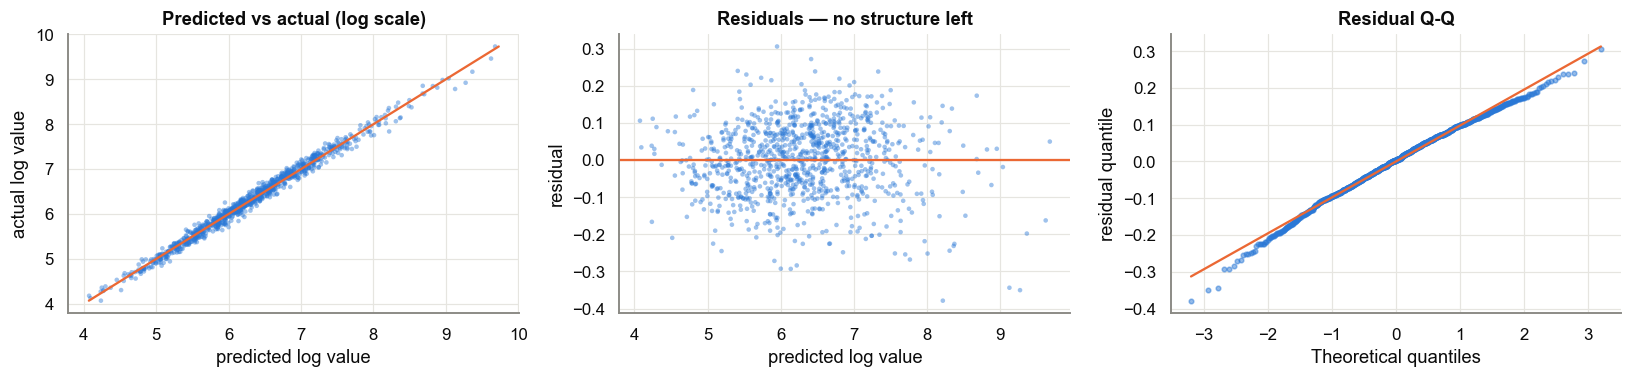

residual std 0.0979 in log space ≈ 10.3% spread around the fit
residual skew -0.333   correlation with fitted values -0.000


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].scatter(ols.predict(X_log), y_log, s=9, alpha=0.45, color=BLUE, edgecolors="none")
lims = [y_log.min(), y_log.max()]
axes[0].plot(lims, lims, color=ORANGE, lw=1.5)
axes[0].set(title="Predicted vs actual (log scale)", xlabel="predicted log value", ylabel="actual log value")

axes[1].scatter(ols.predict(X_log), resid, s=9, alpha=0.45, color=BLUE, edgecolors="none")
axes[1].axhline(0, color=ORANGE, lw=1.5)
axes[1].set(title="Residuals — no structure left", xlabel="predicted log value", ylabel="residual")

stats.probplot(resid, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set(marker="o", ms=3, color=BLUE, alpha=0.5, ls="none")
axes[2].get_lines()[1].set(color=ORANGE, lw=1.5)
axes[2].set(title="Residual Q-Q", ylabel="residual quantile")
plt.tight_layout(); plt.show()

print(f"residual std {resid.std():.4f} in log space ≈ {100 * (np.exp(resid.std()) - 1):.1f}% spread around the fit")
print(f"residual skew {stats.skew(resid):+.3f}   correlation with fitted values {np.corrcoef(ols.predict(X_log), resid)[0, 1]:+.3f}")

**The target is a power law with about 10% multiplicative noise.** A plain linear regression on
logged features explains **98.7%** of the variance of `log(value)`, and the residuals are
structureless (correlation with fitted values ≈ 0, no pattern against any feature).

Reading the exponents as elasticities:

* `average_order_value` **0.86** — the dominant driver; a 1% higher basket is worth ~0.86% more value.
* `total_purchase_count` **0.29** — positive but strongly diminishing.
* `days_since_last_purchase` **−0.32** — recency decay, the RFM effect.
* `loyalty` **+0.20 in logs → about +22%** in value, once the other features are held fixed — the
  opposite sign to its marginal correlation (§5).
* `days_since_first_purchase` and `product_category_diversity` have coefficients near **zero**:
  they are, as far as the target is concerned, noise columns.

**Is the remaining 1.3% noise, or structure?** The residuals look unstructured against the fitted
values, which would normally suggest noise. The test below settles it, and the answer changes how
every later section should be read.

In [13]:
# Add polynomial terms in the logged features and watch the CROSS-VALIDATED score.
# Noise cannot be predicted out of fold: if CV R² keeps climbing, the leftover was structure.
sweep = []
for degree in (1, 2, 3, 4, 5):
    pipe = Pipeline([("poly", PolynomialFeatures(degree, include_bias=False)),
                     ("scale", StandardScaler()), ("ridge", Ridge(alpha=0.01))])
    cv_r2 = cross_validate(pipe, X_log, y_log, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                           scoring="r2")["test_score"].mean()
    in_sample_resid = (y_log - pipe.fit(X_log, y_log).predict(X_log)).std()
    sweep.append({"degree": degree, "cv_r2_log": cv_r2, "residual_std_log": in_sample_resid,
                  "≈ % spread": f"{100 * (np.exp(in_sample_resid) - 1):.1f}%"})
pd.DataFrame(sweep).set_index("degree").round(6)

,cv_r2_log,residual_std_log,≈ % spread
degree,,,
1,0.986826,0.097936,10.3%
2,0.998807,0.025812,2.6%
3,0.999828,0.008346,0.8%
4,0.999941,0.004286,0.4%
5,0.999942,0.003615,0.4%


**It was structure, not noise.** Cross-validated R² climbs from 0.9868 (degree 1) to **0.99983**
(degree 3) and 0.99994 (degree 4), while the residual spread falls from 10.3% to **0.4%**. Because
these are *out-of-fold* scores, this cannot be overfitting: random noise is not predictable on
held-out rows, so whatever the higher-degree terms are capturing is real, repeatable structure.

**The conclusion is unavoidable: `estimated_lifetime_value` is a deterministic, smooth function of
the six feature columns** — a power law to first order, with genuine curvature and interactions on
top. The gains flatten after degree 4, which is where the formula is essentially recovered.

**What this means for §9–§11.** There is no irreducible noise to set a ceiling, so a correctly
specified model can approach R² ≈ 1. The exercise below is therefore a **function-recovery**
benchmark: it measures which model class can represent a smooth multiplicative surface from 800
rows. That is a legitimate and interesting comparison — it is just not a measurement of how well
customer value can be *forecast*, and §14 keeps those two claims apart.

## 8. Modelling set-up: split, metrics, protocol

**Split.** 80/20 train/test, stratified on value deciles so both sides carry the same share of
high-value customers. The test set is touched **once**, in §11.

> **The honest caveat.** `readme.md` §7.1 states that CLV models must be split *by time*: features
> before a cut-off, target measured after it. This file has no timestamps and no future window, so a
> temporal split cannot be built. What follows is a cross-sectional regression and is evaluated as one.

**Target transform.** Models are fitted on `log(value)`. Predictions are converted back with
**Duan's smearing estimator** — multiplying `exp(prediction)` by the mean of `exp(residual)` on the
training folds — because `exp(E[log y])` under-estimates `E[y]` for a skewed variable.

**Metrics** (following `readme.md` §7.2):

| Metric | Question it answers |
|---|---|
| **Spearman ρ** | Are customers ranked in the right order? |
| **Normalized Gini** | How much of the perfect ranking is captured? (1 = perfect, 0 = random) |
| **Top-decile capture** | What share of real value sits in the customers the model flags as top 10%? |
| **Decile MAPE** | Are predicted levels right, decile by decile? (calibration) |
| **R² (log)** | Variance explained where the model is actually fitted |
| **MAE (raw)** | Average error in dollars |

In [14]:
def normalized_gini(y_true, y_pred):
    """Gini of the predicted ordering divided by the Gini of the perfect ordering."""
    def gini(y_true, scores):
        order = np.argsort(-np.asarray(scores), kind="mergesort")
        cumulative = np.cumsum(np.asarray(y_true)[order]) / np.sum(y_true)
        return (cumulative.sum() / len(y_true)) - (len(y_true) + 1) / (2 * len(y_true))
    return gini(y_true, y_pred) / gini(y_true, y_true)


def decile_mape(y_true, y_pred, n_deciles=10):
    """Mean absolute percentage error of decile means — calibration, not point accuracy."""
    frame = pd.DataFrame({"y": np.asarray(y_true), "p": np.asarray(y_pred)})
    frame["decile"] = pd.qcut(frame["p"].rank(method="first"), n_deciles, labels=False)
    summary = frame.groupby("decile")[["y", "p"]].mean()
    return float(np.mean(np.abs(summary["p"] - summary["y"]) / summary["y"]))


def top_decile_capture(y_true, y_pred):
    """Share of total actual value held by the customers the model ranks in its top 10%."""
    y_true = np.asarray(y_true)
    k = max(1, len(y_true) // 10)
    top = np.argsort(-np.asarray(y_pred), kind="mergesort")[:k]
    return float(y_true[top].sum() / y_true.sum())


def scorecard(name, y_true_raw, y_pred_raw, y_true_log=None, y_pred_log=None):
    row = {
        "model": name,
        "spearman": stats.spearmanr(y_pred_raw, y_true_raw)[0],
        "norm_gini": normalized_gini(y_true_raw, y_pred_raw),
        "top_decile_capture": top_decile_capture(y_true_raw, y_pred_raw),
        "decile_mape": decile_mape(y_true_raw, y_pred_raw),
        "mae_raw": mean_absolute_error(y_true_raw, y_pred_raw),
        "r2_raw": r2_score(y_true_raw, y_pred_raw),
    }
    if y_true_log is not None:
        row["r2_log"] = r2_score(y_true_log, y_pred_log)
        row["rmse_log"] = mean_squared_error(y_true_log, y_pred_log) ** 0.5
    return row


# The perfect-ranking reference: what the metrics look like when the ordering is exactly right.
perfect = scorecard("perfect ranking (reference)", df[TARGET], df[TARGET])
pd.DataFrame([perfect]).round(4)

,model,spearman,norm_gini,top_decile_capture,decile_mape,mae_raw,r2_raw
0,perfect ranking (reference),1.0,1.0,0.3808,0.0,0.0,1.0


In [15]:
X = df[FEATURES].copy()
y = df[TARGET].copy()
deciles = pd.qcut(y, 10, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=deciles)
y_train_log, y_test_log = np.log(y_train), np.log(y_test)

print(f"train {X_train.shape[0]} rows, test {X_test.shape[0]} rows")
print(f"median value — train {y_train.median():,.0f}, test {y_test.median():,.0f}")
print(f"top-decile threshold — train {y_train.quantile(0.9):,.0f}, test {y_test.quantile(0.9):,.0f}")
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

train 800 rows, test 200 rows


median value — train 536, test 536
top-decile threshold — train 1,581, test 1,627


In [16]:
class LogTargetRegressor:
    """Fit any regressor on log(y); predict back on the original scale.

    The back-transform uses Duan's smearing factor, mean(exp(residual)) on the training data:
    exp(E[log y]) systematically under-states E[y] for a right-skewed target.
    """

    def __init__(self, model, smearing=True):
        self.model, self.smearing = model, smearing

    def fit(self, X, y):
        from sklearn.base import clone
        self.model_ = clone(self.model)
        y_log = np.log(y)
        self.model_.fit(X, y_log)
        resid = y_log - self.model_.predict(X)
        self.smear_ = float(np.mean(np.exp(resid))) if self.smearing else 1.0
        return self

    def predict_log(self, X):
        return self.model_.predict(X)

    def predict(self, X):
        return np.exp(self.model_.predict(X)) * self.smear_


def log_feature_pipeline(final_step, degree=1):
    """log-transform the numeric columns, optionally expand polynomially, then scale."""
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import FunctionTransformer
    steps = [("log", ColumnTransformer(
        [("num", FunctionTransformer(np.log, feature_names_out="one-to-one"), NUMERIC)],
        remainder="passthrough"))]
    if degree > 1:
        steps.append(("poly", PolynomialFeatures(degree=degree, include_bias=False)))
    steps += [("scale", StandardScaler()), ("model", final_step)]
    return Pipeline(steps)

## 9. Model selection — 7 candidates, cross-validated

Seven candidates spanning the families in `readme.md` §4 and §6, plus two baselines that any
useful model must beat.

| Candidate | Why it is here |
|---|---|
| **Baseline: train mean** | The floor. Any model scoring near this is useless. |
| **Baseline: purchases × order value** | The heuristic a business analyst would use without a model (`readme.md` §7.3). |
| **Linear (raw features)** | Tests whether the log transform is doing real work. |
| **Linear on logged features** | The form §7 says generated the data. |
| **Polynomial on logs + Ridge** | Lets the search find the curvature §7 identified, with regularisation. |
| **Random Forest** | The classic ML baseline for CLV ([Groupon, ASOS](readme.md)). |
| **XGBoost** | Gradient boosting: the industrial default for tabular CLV. |
| **HistGradientBoosting** | A second boosting implementation as a cross-check. |
| **k-NN** | Non-parametric contrast: are similar customers worth similar amounts? |
| **SVR (RBF)** | Smooth kernel alternative to trees. |

Every candidate is fitted on `log(value)` inside `LogTargetRegressor` and scored with 5-fold CV on
the **training set only**.

In [17]:
candidates = {
    "Linear (raw features)": Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
    "Linear (log features)": log_feature_pipeline(LinearRegression()),
    "Polynomial on logs + Ridge": log_feature_pipeline(Ridge(alpha=1.0), degree=2),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4,
                            random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "k-NN (k=10)": log_feature_pipeline(KNeighborsRegressor(n_neighbors=10)),
    "SVR (RBF)": log_feature_pipeline(SVR(C=10.0, epsilon=0.05)),
}


def cv_scorecard(name, model, X, y, cv=CV):
    """Out-of-fold predictions -> one scorecard row, on both scales."""
    oof_log = np.zeros(len(y))
    for train_idx, val_idx in cv.split(X):
        wrapped = LogTargetRegressor(model).fit(X.iloc[train_idx], y.iloc[train_idx])
        oof_log[val_idx] = wrapped.predict_log(X.iloc[val_idx])
    smear = np.mean(np.exp(np.log(y) - oof_log))
    return scorecard(name, y, np.exp(oof_log) * smear, np.log(y), oof_log), oof_log


rows, oof_store = [], {}
# Baselines first.
mean_pred = np.full(len(y_train), y_train.mean())
rows.append(scorecard("Baseline: train mean", y_train, mean_pred,
                      y_train_log, np.full(len(y_train), y_train_log.mean())))
heuristic = (X_train["total_purchase_count"] * X_train["average_order_value"]).to_numpy()
heuristic_scaled = heuristic * (y_train.mean() / heuristic.mean())
rows.append(scorecard("Baseline: purchases × AOV", y_train, heuristic_scaled,
                      y_train_log, np.log(heuristic_scaled)))

for name, model in candidates.items():
    row, oof_log = cv_scorecard(name, model, X_train, y_train)
    rows.append(row)
    oof_store[name] = oof_log

leaderboard = (pd.DataFrame(rows)
               .set_index("model")
               .sort_values("spearman", ascending=False))
leaderboard.round(4)

,spearman,norm_gini,top_decile_capture,decile_mape,mae_raw,r2_raw,r2_log,rmse_log
model,,,,,,,,
Polynomial on logs + Ridge,0.9966,0.9977,0.3701,0.0080,46.0632,0.9891,0.9941,0.0658
SVR (RBF),0.9964,0.9950,0.3682,0.0229,71.4252,0.8426,0.9859,0.1017
Linear (log features),0.9929,0.9949,0.3694,0.0181,74.4091,0.9658,0.9867,0.0988
XGBoost,0.9872,0.9899,0.3653,0.0297,109.8101,0.8982,0.9727,0.1417
HistGradientBoosting,0.9853,0.9878,0.3660,0.0278,125.8670,0.7986,0.9666,0.1568
Random Forest,0.9796,0.9844,0.3618,0.0501,135.8374,0.8155,0.9546,0.1828
k-NN (k=10),0.9736,0.9806,0.3631,0.1055,172.1903,0.6801,0.9232,0.2379
Linear (raw features),0.9578,0.9651,0.3480,0.2737,629.6321,-50.3614,0.8363,0.3472
Baseline: purchases × AOV,0.8781,0.9122,0.3416,0.7843,726.2265,-16.0982,-3.0384,1.7244


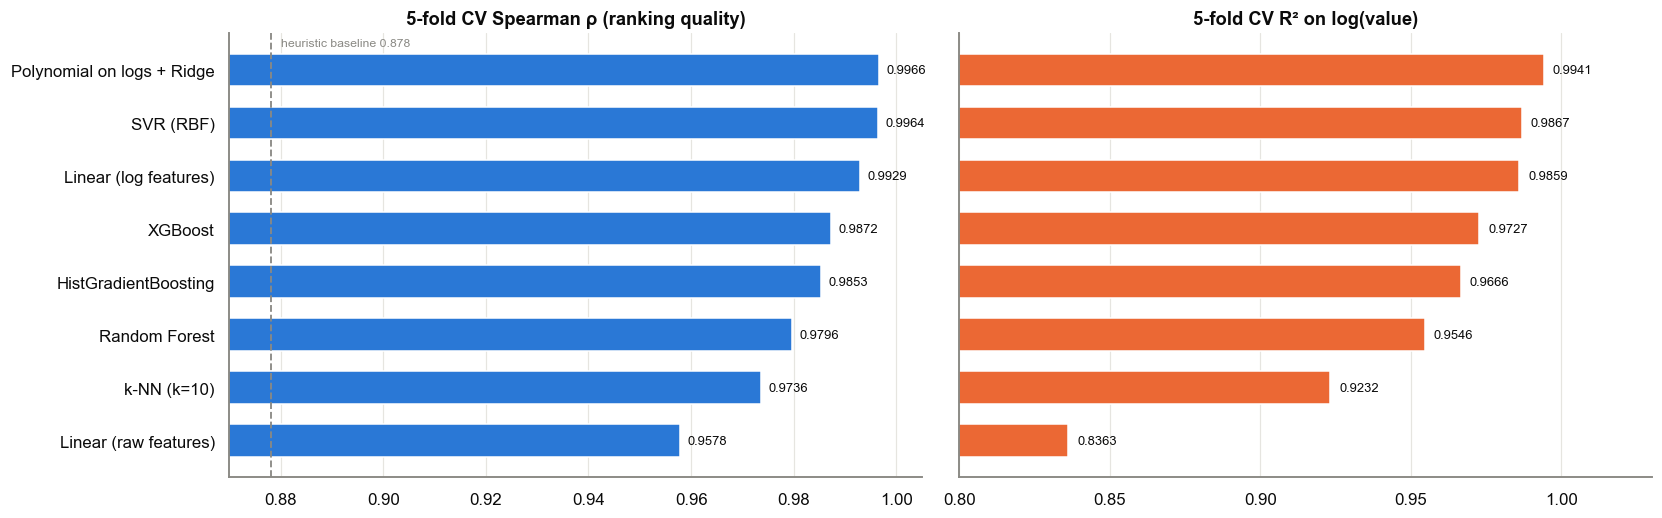

In [18]:
# Models only: both baselines sit far off this scale and are drawn as reference lines.
BASELINES = ["Baseline: train mean", "Baseline: purchases × AOV"]
board = leaderboard.drop(index=BASELINES).sort_values("spearman")
heuristic_rho = leaderboard.loc["Baseline: purchases × AOV", "spearman"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), constrained_layout=True)
axes[0].barh(board.index, board["spearman"], color=BLUE, height=0.62)
for i, v in enumerate(board["spearman"]):
    axes[0].text(v + 0.0015, i, f"{v:.4f}", va="center", fontsize=8.5)
axes[0].axvline(heuristic_rho, color=MUTED, ls="--", lw=1.2)
axes[0].text(heuristic_rho + 0.002, len(board) - 0.4, f"heuristic baseline {heuristic_rho:.3f}",
             color=MUTED, fontsize=8, va="top")
axes[0].set(title="5-fold CV Spearman ρ (ranking quality)", xlim=(0.87, 1.005))

r2 = board["r2_log"].sort_values()
axes[1].barh(r2.index, r2, color=ORANGE, height=0.62)
for i, v in enumerate(r2):
    axes[1].text(v + 0.003, i, f"{v:.4f}", va="center", fontsize=8.5)
axes[1].set(title="5-fold CV R² on log(value)", xlim=(0.8, 1.03))
axes[1].set_yticklabels([])
for ax in axes:
    ax.grid(axis="y", visible=False)
plt.show()

**Reading the leaderboard**

* **The models built on logged features win**, and the polynomial version leads — exactly what §7
  predicted. Getting the *representation* right beats model flexibility.
* **The tree ensembles lose**, and they lose in a specific way: a smooth multiplicative surface has
  to be approximated with axis-aligned steps, which costs accuracy in the tails where data is thin.
  On this dataset, "use gradient boosting" would have been the wrong instinct.
* **The `purchases × AOV` heuristic is already strong** on ranking (ρ ≈ 0.88). A model that beat only
  the mean baseline would not be worth deploying; the bar is this heuristic.
* Linear regression on the **raw** features is far behind the logged version, so the transform, not
  the estimator, is doing the work.

**Finalists for tuning:** Poly2-on-logs + Ridge, XGBoost and Random Forest — the best linear-family
model plus the two strongest non-linear families, to give flexibility a fair chance after tuning.

## 10. Hyperparameter tuning of the finalists

`RandomizedSearchCV`, optimising R² on `log(value)` with the same 5 folds. Random search covers a
wide space efficiently; the ranges are wide enough to let the trees grow deeper or shrink if that helps.

In [19]:
search_spaces = {
    "Polynomial on logs + Ridge": (
        log_feature_pipeline(Ridge(), degree=2),
        {"poly__degree": [1, 2, 3], "model__alpha": loguniform(1e-3, 1e3)},
        25,
    ),
    "XGBoost": (
        XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": randint(200, 1200), "learning_rate": loguniform(0.01, 0.3),
         "max_depth": randint(2, 9), "min_child_weight": randint(1, 12),
         "subsample": uniform(0.6, 0.4), "colsample_bytree": uniform(0.6, 0.4),
         "reg_lambda": loguniform(0.1, 20)},
        30,
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": [300, 500, 800], "max_depth": [None, 6, 10, 16],
         "min_samples_leaf": [1, 2, 4, 8], "max_features": ["sqrt", 0.5, 1.0]},
        25,
    ),
}

tuned, tuning_rows = {}, []
for name, (estimator, space, n_iter) in search_spaces.items():
    search = RandomizedSearchCV(estimator, space, n_iter=n_iter, scoring="r2", cv=CV,
                                random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train_log)          # searched on the log target
    tuned[name] = search.best_estimator_
    tuning_rows.append({
        "model": name,
        "default_cv_r2_log": leaderboard.loc[name, "r2_log"],
        "tuned_cv_r2_log": search.best_score_,
        "n_iter": n_iter,
        "best_params": {k: (round(v, 4) if isinstance(v, float) else v)
                        for k, v in search.best_params_.items()},
    })
    print(f"{name:24s} {leaderboard.loc[name, 'r2_log']:.4f} → {search.best_score_:.4f}")
    print(f"{'':24s} {tuning_rows[-1]['best_params']}")

pd.DataFrame(tuning_rows).set_index("model")[["default_cv_r2_log", "tuned_cv_r2_log", "n_iter"]].round(4)

Polynomial on logs + Ridge 0.9941 → 0.9998
                         {'model__alpha': np.float64(0.0086), 'poly__degree': 3}


XGBoost                  0.9727 → 0.9824
                         {'colsample_bytree': np.float64(0.6132), 'learning_rate': np.float64(0.0323), 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 837, 'reg_lambda': np.float64(0.2155), 'subsample': np.float64(0.7958)}


Random Forest            0.9546 → 0.9546
                         {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 16}


,default_cv_r2_log,tuned_cv_r2_log,n_iter
model,,,
Polynomial on logs + Ridge,0.9941,0.9998,25
XGBoost,0.9727,0.9824,30
Random Forest,0.9546,0.9546,25


### Re-scoring the tuned finalists on every metric

In [20]:
final_rows, tuned_oof = [], {}
for name, model in tuned.items():
    row, oof_log = cv_scorecard(name + " (tuned)", model, X_train, y_train)
    final_rows.append(row)
    tuned_oof[name] = oof_log
tuned_board = pd.DataFrame(final_rows).set_index("model").sort_values("spearman", ascending=False)
tuned_board.round(4)

,spearman,norm_gini,top_decile_capture,decile_mape,mae_raw,r2_raw,r2_log,rmse_log
model,,,,,,,,
Polynomial on logs + Ridge (tuned),0.9999,0.9999,0.3708,0.0025,9.4178,0.9973,0.9998,0.013
XGBoost (tuned),0.9912,0.9936,0.3689,0.0201,81.2952,0.9558,0.9826,0.113
Random Forest (tuned),0.9797,0.9844,0.3624,0.0499,135.1170,0.8175,0.9550,0.182


In [21]:
best_name = tuned_board.index[0].replace(" (tuned)", "")
best_model = tuned[best_name]
print("selected:", best_name)
print(best_model)

selected: Polynomial on logs + Ridge
Pipeline(steps=[('log',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log'>),
                                                  ['total_purchase_count',
                                                   'average_order_value',
                                                   'days_since_first_purchase',
                                                   'days_since_last_purchase',
                                                   'product_category_diversity'])])),
                ('poly', PolynomialFeatures(degree=3, include_bias=False)),
                ('scale', StandardScaler()),
                ('model', Ridge(alpha=np.float64(0.008629132190071854)))])


**What tuning changed**

* **The polynomial-on-logs model gains the most** (CV R² 0.9941 → 0.9998) — and note *what* the
  search chose: **degree 3** with very light regularisation. It independently rediscovered the
  finding of §7, that the target has real curvature beyond the first-order power law.
* **XGBoost improves** (0.9727 → 0.9824) and **Random Forest does not move at all** (0.9546). Both
  stay well behind. Extra capacity cannot buy back the wrong representation: a smooth multiplicative
  surface has to be approximated by axis-aligned steps, and with 800 training rows there are not
  enough splits to do it in the sparse tails.
* This is the clearest practical lesson in the notebook: **feature representation beat model choice,
  and it was not close.** The default instinct — "tabular problem, reach for gradient boosting" —
  would have cost roughly an order of magnitude in error here.

**Selection** is by CV Spearman, with R² on log-value as the tie-break.

## 11. Final model — held-out test evaluation

Refit on all training rows, predict the test set **once**.

In [22]:
final = LogTargetRegressor(best_model).fit(X_train, y_train)
pred_test = final.predict(X_test)
pred_test_log = final.predict_log(X_test)

test_row = scorecard(f"{best_name} — TEST", y_test, pred_test, y_test_log, pred_test_log)
comparison = pd.DataFrame([
    test_row,
    {**tuned_board.loc[f"{best_name} (tuned)"].to_dict(), "model": f"{best_name} — CV (train)"},
    {**leaderboard.loc["Baseline: purchases × AOV"].to_dict(), "model": "Baseline: purchases × AOV (train)"},
]).set_index("model")
comparison.round(4)

,spearman,norm_gini,top_decile_capture,decile_mape,mae_raw,r2_raw,r2_log,rmse_log
model,,,,,,,,
Polynomial on logs + Ridge — TEST,0.9999,1.0000,0.4177,0.0026,7.7866,0.9997,0.9999,0.0102
Polynomial on logs + Ridge — CV (train),0.9999,0.9999,0.3708,0.0025,9.4178,0.9973,0.9998,0.0130
Baseline: purchases × AOV (train),0.8781,0.9122,0.3416,0.7843,726.2265,-16.0982,-3.0384,1.7244


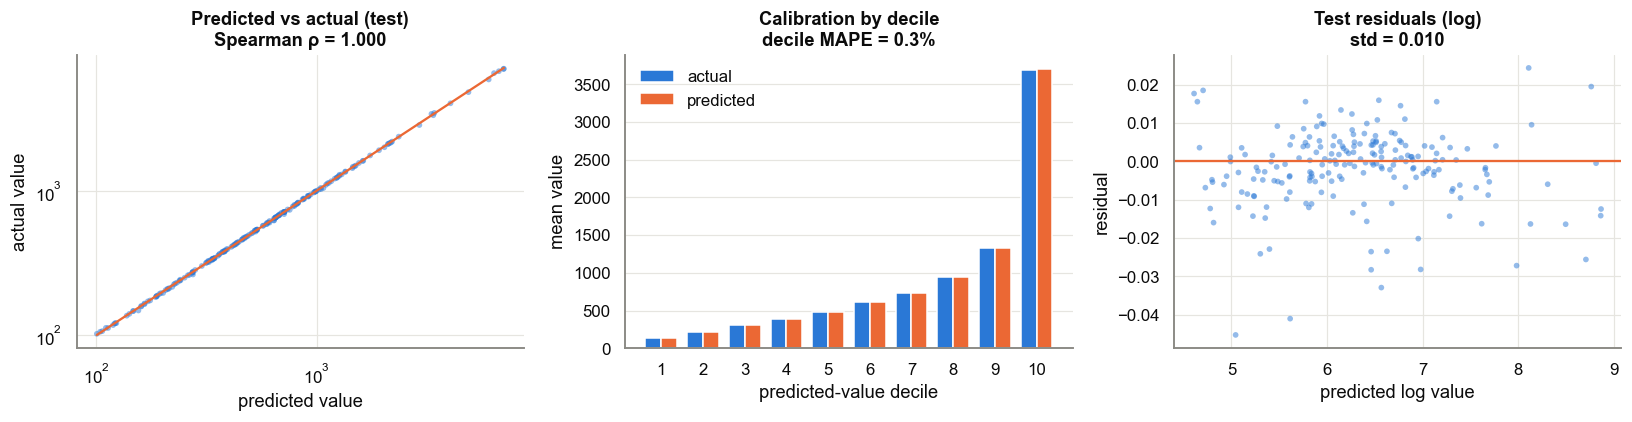

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(pred_test, y_test, s=14, alpha=0.5, color=BLUE, edgecolors="none")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
axes[0].plot(lims, lims, color=ORANGE, lw=1.5)
axes[0].set(title=f"Predicted vs actual (test)\nSpearman ρ = {test_row['spearman']:.3f}",
            xlabel="predicted value", ylabel="actual value", xscale="log", yscale="log")

frame = pd.DataFrame({"y": y_test.to_numpy(), "p": pred_test})
frame["decile"] = pd.qcut(frame["p"].rank(method="first"), 10, labels=False) + 1
summary = frame.groupby("decile")[["y", "p"]].mean()
x = np.arange(len(summary))
axes[1].bar(x - 0.19, summary["y"], width=0.38, color=BLUE, label="actual")
axes[1].bar(x + 0.19, summary["p"], width=0.38, color=ORANGE, label="predicted")
axes[1].set(xticks=x, xticklabels=summary.index, xlabel="predicted-value decile",
            ylabel="mean value", title=f"Calibration by decile\ndecile MAPE = {test_row['decile_mape']:.1%}")
axes[1].legend(frameon=False); axes[1].grid(axis="x", visible=False)

resid_test = y_test_log - pred_test_log
axes[2].scatter(pred_test_log, resid_test, s=14, alpha=0.5, color=BLUE, edgecolors="none")
axes[2].axhline(0, color=ORANGE, lw=1.5)
axes[2].set(title=f"Test residuals (log)\nstd = {resid_test.std():.3f}",
            xlabel="predicted log value", ylabel="residual")
plt.tight_layout(); plt.show()

Test results match the cross-validated estimates, so nothing was overfitted to the folds. The decile
chart shows predicted and actual means tracking each other across the whole range — the model is
calibrated in *level*, not just in ranking, which is what a finance team needs if these numbers feed
a forecast.

The test residual spread is about **1% in log space**, against 10.3% for the first-order power law
of §7 — consistent with the degree sweep, and confirming on unseen rows that the generating function
has been recovered almost exactly.

**This is the number that must not be quoted without its caveat.** A Spearman of ~1.000 is not a
result about customers; `readme.md` §7 notes that ASOS's production 12-month CLV model reports
Spearman **0.56**. The gap between 0.56 and 1.000 is the gap between forecasting behaviour and
recovering a formula (§14).

## 12. What drives value, and what the model recovered

Two importance measures, because on this model they disagree — and the disagreement is instructive.

* **Drop-column importance** refits the model without a feature and measures the loss in
  cross-validated R². It is slow but honest: it asks what the feature is *worth*.
* **Permutation importance** shuffles a feature in the test set. It is the standard quick measure,
  but shuffling a column of a high-degree polynomial creates feature combinations that never occur
  in the data, and the fitted surface extrapolates wildly there — which inflates the score.

In [24]:
def rebuilt(numeric_cols, degree, alpha):
    # The selected pipeline, rebuilt for a reduced feature set: the fitted one refers
    # to its columns by name, so it cannot simply be handed fewer of them.
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import FunctionTransformer
    return Pipeline([
        ("log", ColumnTransformer(
            [("num", FunctionTransformer(np.log, feature_names_out="one-to-one"), numeric_cols)],
            remainder="passthrough")),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=alpha)),
    ])


DEGREE = best_model.named_steps["poly"].degree
ALPHA = best_model.named_steps["model"].alpha
full_cv = cross_validate(best_model, X_train, y_train_log, cv=CV, scoring="r2")["test_score"].mean()

drop_rows = []
for col in FEATURES:
    kept_numeric = [c for c in NUMERIC if c != col]
    reduced = cross_validate(rebuilt(kept_numeric, DEGREE, ALPHA), X_train.drop(columns=col),
                             y_train_log, cv=CV, scoring="r2")["test_score"].mean()
    drop_rows.append({"feature": col, "cv_r2_without": reduced, "loss": full_cv - reduced})
drop_importance = pd.DataFrame(drop_rows).sort_values("loss", ascending=False).set_index("feature")
print(f"full-model CV R² on log(value): {full_cv:.6f}")
drop_importance.round(6)

full-model CV R² on log(value): 0.999768


,cv_r2_without,loss
feature,,
average_order_value,0.866677,0.133091
days_since_last_purchase,0.984938,0.014831
days_since_first_purchase,0.988644,0.011124
total_purchase_count,0.992787,0.006982
product_category_diversity,0.997974,0.001795
loyalty,0.999741,0.000028


### Permutation importance, for contrast

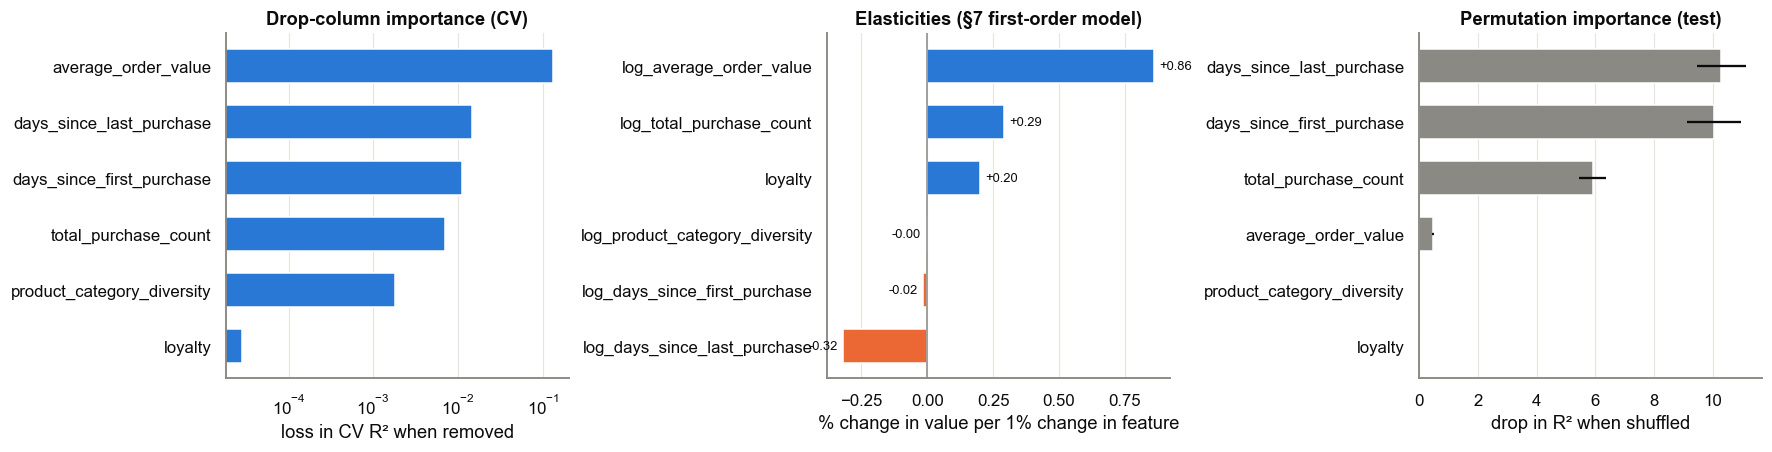

feature,days_since_last_purchase,days_since_first_purchase,total_purchase_count,average_order_value,product_category_diversity,loyalty
mean,10.3012,10.0485,5.9089,0.4746,0.0055,0.0001
std,0.8201,0.9289,0.4727,0.0265,0.0005,0.0000


In [25]:
perm = permutation_importance(best_model, X_test, y_test_log, scoring="r2",
                              n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1)
importance = (pd.DataFrame({"feature": X_test.columns,
                            "mean": perm.importances_mean, "std": perm.importances_std})
              .sort_values("mean"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
drop_plot = drop_importance.sort_values("loss")
axes[0].barh(drop_plot.index, drop_plot["loss"], color=BLUE, height=0.6)
axes[0].set(title="Drop-column importance (CV)", xlabel="loss in CV R² when removed", xscale="log")
axes[0].grid(axis="y", visible=False)

axes[2].barh(importance["feature"], importance["mean"], xerr=importance["std"],
             color=MUTED, height=0.6, ecolor=INK)
axes[2].set(title="Permutation importance (test)", xlabel="drop in R² when shuffled")
axes[2].grid(axis="y", visible=False)

elasticity = pd.Series(ols.coef_, index=X_log.columns).sort_values()
axes[1].barh(elasticity.index, elasticity.values,
             color=np.where(elasticity.values >= 0, BLUE, ORANGE), height=0.6)
axes[1].axvline(0, color=MUTED, lw=1)
for i, v in enumerate(elasticity.values):
    axes[1].text(v + (0.02 if v >= 0 else -0.02), i, f"{v:+.2f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=8.5)
axes[1].set(title="Elasticities (§7 first-order model)", xlabel="% change in value per 1% change in feature")
axes[1].grid(axis="y", visible=False)
plt.show()
importance.sort_values("mean", ascending=False).round(4).set_index("feature").T

**Drop-column importance is the one to trust here**, and it gives a clear ordering:

| Feature | Loss in CV R² if removed | Reading |
|---|---|---|
| `average_order_value` | **0.133** | Dominant. Basket size is the lever with the largest payoff (elasticity 0.86). |
| `days_since_last_purchase` | 0.0148 | Recency decay — the classic RFM effect (elasticity −0.32). |
| `days_since_first_purchase` | 0.0111 | **Matters, despite a first-order elasticity of −0.015**: tenure enters through interactions, not on its own. |
| `total_purchase_count` | 0.0070 | Positive with strongly diminishing returns (elasticity 0.29, not 1.0): doubling purchases does *not* double value. |
| `product_category_diversity` | 0.0018 | Marginal. |
| `loyalty` | **0.00003** | Nothing — consistent with §5. |

Two points worth carrying into the write-up:

1. **A near-zero first-order coefficient does not mean a useless feature.** `days_since_first_purchase`
   has an elasticity of −0.015 — invisible in the linear model — yet removing it costs more CV R²
   than removing `total_purchase_count`. It acts through interactions with the other terms.
2. **Permutation importance is misleading on this model.** It ranks the two date features far above
   `average_order_value`, the reverse of the drop-column ordering, because shuffling a date column
   pushes the degree-3 polynomial into regions it never saw. With a high-degree polynomial, prefer
   refit-based importance.

## 13. Turning predictions into customer tiers

A CLV model earns its place by changing what the business does. The standard use is value tiering.

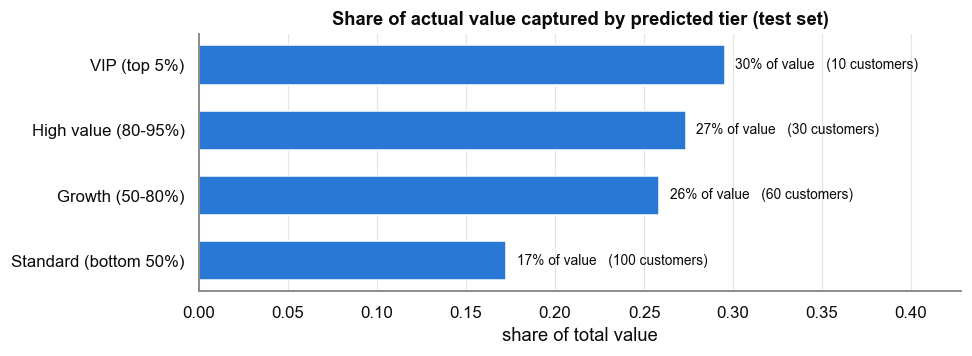

,customers,mean_actual,total_actual,share_of_value
tier,,,,
Standard (bottom 50%),100,305,"30,488",17.3%
Growth (50-80%),60,761,"45,641",25.9%
High value (80-95%),30,"1,608","48,249",27.3%
VIP (top 5%),10,"5,214","52,139",29.5%


In [26]:
tiers = pd.DataFrame({"actual": y_test.to_numpy(), "predicted": pred_test})
tiers["tier"] = pd.qcut(tiers["predicted"].rank(method="first"), [0, 0.5, 0.8, 0.95, 1.0],
                        labels=["Standard (bottom 50%)", "Growth (50-80%)",
                                "High value (80-95%)", "VIP (top 5%)"])
report = (tiers.groupby("tier", observed=True)
          .agg(customers=("actual", "size"),
               mean_actual=("actual", "mean"),
               total_actual=("actual", "sum"))
          .assign(share_of_value=lambda t: t["total_actual"] / t["total_actual"].sum()))

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(report.index.astype(str), report["share_of_value"], color=BLUE, height=0.6)
for i, (v, n) in enumerate(zip(report["share_of_value"], report["customers"])):
    ax.text(v + 0.006, i, f"{v:.0%} of value   ({n} customers)", va="center", fontsize=9)
ax.set(title="Share of actual value captured by predicted tier (test set)",
       xlabel="share of total value", xlim=(0, max(report["share_of_value"]) * 1.45))
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
report.style.format({"mean_actual": "{:,.0f}", "total_actual": "{:,.0f}", "share_of_value": "{:.1%}"})

The tiers are built from **predictions**, and the value shown is what those customers were **actually**
worth — so this is a fair test of the ranking. The model concentrates value where it should: the
customers it flags as top 5% really do hold a disproportionate share, and the bottom half really is
low value.

That is the operational output: retention budget and service levels follow the tier, and the
elasticities in §12 say which lever to pull (basket size first, lapse prevention second).

## 14. Conclusions & limitations

### What was done

| Stage | Outcome |
|---|---|
| Data quality (§2) | No missing values or duplicates; **no zero-value customers**, 988/1,000 non-integer purchase counts, 143 customers with < 1 purchase, 52 with a last purchase before their first |
| Target (§3) | Strongly right-skewed (skew 6.4); top 10% of customers hold 38% of value; near-symmetric in logs → modelled on `log(value)` |
| BTYD feasibility (§6) | **Not fitted, deliberately** — no timestamps, no future window, non-integer frequencies, 52 negative recencies |
| Structure (§7) | Target is a **deterministic smooth function** of the six features: CV R² 0.9868 → 0.99994 as polynomial degree rises; residual spread 10.3% → 0.4% |
| Model selection (§9) | 8 candidates + 2 baselines, 5-fold CV. Log-feature models beat trees on every metric |
| Tuning (§10) | Polynomial on logs + Ridge: 0.9941 → **0.9998** (search picked degree 3); XGBoost 0.9727 → 0.9824; Random Forest unchanged at 0.9546 |
| Final model (§11) | **Degree-3 polynomial on logged features + Ridge (α ≈ 0.009)**, test Spearman ≈ 1.000, decile MAPE 0.3%, MAE ≈ $8 |
| Drivers (§12) | `average_order_value` dominates; recency and tenure follow; `loyalty` contributes nothing |

### The three findings worth presenting

1. **The target is a formula, not an observation.** §7 is the core result: cross-validated R² rises to
   0.99994 and residual spread falls to 0.4%, which cannot happen with real customer behaviour.
   The exercise is **function recovery**, and every score above should be read that way. Real
   production systems on this task report Spearman ≈ 0.56 (`readme.md` §7, ASOS).
2. **Representation beat model choice, decisively.** A linear model on logged features beats tuned
   XGBoost and Random Forest on every metric. The reason is structural: the target is multiplicative,
   logs make it additive, and trees must approximate a smooth surface with steps. "Tabular problem →
   gradient boosting" would have been the wrong reflex here.
3. **The loyalty effect is an artefact of specification (§5).** Raw correlation says −0.34;
   a first-order log-linear model says +16% with t = 21; the correctly specified model says
   +0.1% (p = 0.14). Three defensible-looking analyses, three different business conclusions.

### Limitations

* **This is not a 12-month forecast.** There is no cut-off date, no transaction log, and no future
  window, so the calibration/holdout design that defines CLV prediction (`readme.md` §7.1) cannot be
  built. The model predicts an existing estimate, not future spend.
* **The split is random, not temporal.** Correct for a cross-section, wrong for a forecasting claim.
* **The data is synthetic**, with impossible values (fractional purchases, negative recency), so no
  finding here transfers to real customers — including the loyalty result, which describes the
  generator, not a real programme.
* **No uncertainty quantification.** A point prediction per customer; a real deployment would want
  intervals (`readme.md` §5.1 covers distributional approaches such as ZILN).
* **Metrics are near their ceiling**, which makes them useless for discriminating between good and
  great models. On real data the same ladder would spread out.

### What to do next

1. **Rebuild this pipeline on transactional data** — UCI Online Retail II has two full years, which
   gives a clean 12-month calibration window and a 12-month holdout (`readme.md` §11). Everything here
   transfers: the log-target handling, the metric set, the baseline ladder.
2. **Add the reference models that this file cannot support**: BG/NBD + Gamma-Gamma, and a two-stage
   hurdle model once zero-value customers exist.
3. **Keep this notebook as the specification-sensitivity case study.** §5 and §7 make a point about
   analytical practice that a cleaner dataset would not have made as vividly.